#### Laurent Jutras-Dubé
  
<br>

This Jupyter notebook reproduces the simulations shown in Figure 5 of the paper titled "Optogenetic-Programmable Human Embryo Models Elucidate the Interplay Between Tissue Architecture and BMP4 Signaling at the Onset of Gastrulation" by Riccardo De Santis, Laurent Jutras-Dubé, Sophia Bourdrel, Eleni Rice, Francesco Piccolo, and Ali H. Brivanlou.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode
from hexalattice.hexalattice import create_hex_grid
from matplotlib import colors

In [4]:
def integrate(PDEs, n_var, param):
    
    # Integrator and parameters
    integrator = ode(PDEs)
    integrator.set_integrator('lsoda', with_jacobian=False, rtol=1e-4, nsteps=1000)
    integrator.set_f_params(param)
    
    # Initial conditions
    times = param["t"] 
    init_cond = np.zeros(n_var*len(param["x"]))
    integrator.set_initial_value(init_cond, times[0])
    results = [init_cond]
    
    # Integration
    for t in times[1:]:
        integrator.integrate(t)
        if (integrator.successful):
            results.append(integrator.y)
        else:
            print("An error occurred during the integration.")
            break
           
    # Output
    if len(times) > 1:    return np.array(results)
    else:    return results[0]



def compute_BMP4_prod(param):

    x, x_L, s = param["x"], param["x_L"], param["s_B"]
    prod_B = 0.5*np.tanh((x+x_L)/s)+0.5
    prod_B[x>0] = (0.5*np.tanh((-x+x_L)/s)+0.5)[x>0]

    return param["p_B"]*prod_B



def compute_K1_mp(param):

    x = param["x"]
    r = (x-np.max(x)+205.)/160.
    r[r<0.] = 0
    max_K1, min_K1, n_K1 = param["max_K1"], param["min_K1"], param["n_K1"]

    return (max_K1-min_K1)/(1.+r**n_K1)+min_K1



def PDEs_FIG5_mp(t, var, param):
    
    # Position
    x = param["x"]
    dx = x[1]-x[0]

    # NOGGIN, WNT3, NODAL
    var[var < 0.] = 0.
    N = var[:len(x)]
    W = var[len(x):2*len(x)]
    O = var[2*len(x):]

    # Free BMP4
    B_f = param["B_0"]/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["K_S1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)

    # Tension parameter
    T = param["T"]
    
    # nYAP
    n_Y, K_Y = param["n_Y"], param["K_Y"]
    Y = S_1**n_Y/(S_1**n_Y+K_Y**n_Y)*(1.-0.5*T)
    if param["Y_f"] != 0.:    Y =  param["Y_f"]
    
    # nß-CATENIN
    n_C, K_C = param["n_C"], param["K_C"]
    C = W**n_C/(W**n_C+K_C**n_C)*T
    
    # Diffusion terms
    if_light = param["if_light"]
    diff_N, diff_W, diff_O = [np.zeros(len(x)) for k in range(3)]
    diff_N[1:-1] = (N[:-2]-2.*N[1:-1]+N[2:])/dx**2-0.5*(N[:-2]-N[2:])/x[1:-1]/dx
    diff_W[1:-1] = (W[:-2]-2.*W[1:-1]+W[2:])/dx**2-0.5*(W[:-2]-W[2:])/x[1:-1]/dx
    diff_O[1:-1] = (O[:-2]-2.*O[1:-1]+O[2:])/dx**2-0.5*(O[:-2]-O[2:])/x[1:-1]/dx

    # Boundary conditions at the center
    diff_N[0] = 2.*(N[1]-N[0])/dx**2
    diff_W[0] = 2.*(W[1]-W[0])/dx**2
    diff_O[0] = 2.*(O[1]-O[0])/dx**2

    # WNT3 production term
    prod_W = (param["p1_W"]*S_1+param["p2_W"]*C)*(1.-Y)
    
    # PDEs
    d_N = param["p_N"]*S_1+param["D_N"]*diff_N-param["l_N"]*N
    d_W = prod_W+param["D_W"]*diff_W-param["l_W"]*W
    d_O = param["p_O"]*C+param["D_O"]*diff_O-param["l_O"]*O

    # Boundary conditions at the edge
    d_N[-1] = 0.
    d_W[-1] = 0.
    d_O[-1] = 0.
    
    return np.concatenate((d_N, d_W, d_O))



def sim_FIG5_mp(param):

    # Position
    x = param["x"]
    
    # NOGGIN, WNT3, NODAL
    results = integrate(PDEs_FIG5_mp, 3, param)
    N = results[:,:len(x)]
    W = results[:,len(x):2*len(x)]
    O = results[:,2*len(x):]
    
    # Free BMP4
    B_f = param["B_0"]/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["K_S1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)

    # Tension parameter
    T = param["T"]
    
    # nYAP
    n_Y, K_Y = param["n_Y"], param["K_Y"]
    Y = S_1**n_Y/(S_1**n_Y+K_Y**n_Y)*(1.-0.5*T)
    if param["Y_f"] != 0.:    Y =  np.zeros(S_1.shape)+param["Y_f"]
    
    # nß-CATENIN
    n_C, K_C = param["n_C"], param["K_C"]
    C = W**n_C/(W**n_C+K_C**n_C)*T
    
    # pSMAD2
    n_2, K_2 = param["n_S2"], param["K_S2"]
    S_2 = O**n_2/(O**n_2+K_2**n_2)
    
    # ISL1
    n_f, K_f = param["n_f"], param["K_f"]
    ISL1 = S_1**n_f/(S_1**n_f+K_f**n_f)
    
    # BRA
    BRA = C**n_f/(C**n_f+K_f**n_f)
    BRA *= S_2**n_f/(S_2**n_f+K_f**n_f)
    BRA *= K_f**n_f/(ISL1**n_f+K_f**n_f)
    
    # SOX2
    SOX2 = K_f**n_f/(S_1**n_f+K_f**n_f)
    SOX2 *= K_f**n_f/(BRA**n_f+K_f**n_f)

    return x, np.array([N,W,O,B_f]), np.array([S_1,Y,C,S_2]), np.array([SOX2,ISL1,BRA])



def PDEs_FIG5_light(t, var, param):
    
    # Distance from the center
    x = param["x"]
    dx = x[1]-x[0]

    # BMP4, NOGGIN, WNT3, NODAL
    var[var < 0.] = 0.
    B = var[:len(x)]
    N = var[len(x):2*len(x)]
    W = var[2*len(x):3*len(x)]
    O = var[3*len(x):]

    # Free BMP4
    B_f = B/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["max_K1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)

    # Tension parameter
    T = param["T"]
    
    # nYAP
    n_Y, K_Y = param["n_Y"], param["K_Y"]
    Y = S_1**n_Y/(S_1**n_Y+K_Y**n_Y)*(1.-0.5*T)
    if param["Y_f"] != 0.:    Y =  param["Y_f"]
    
    # nß-CATENIN
    n_C, K_C = param["n_C"], param["K_C"]
    C = W**n_C/(W**n_C+K_C**n_C)*T
    
    # Diffusion terms
    diff_B, diff_N, diff_W, diff_O = [np.zeros(len(x)) for k in range(4)]
    diff_B[1:-1] = B[:-2]-2.*B[1:-1]+B[2:]
    diff_N[1:-1] = N[:-2]-2.*N[1:-1]+N[2:]
    diff_W[1:-1] = W[:-2]-2.*W[1:-1]+W[2:]
    diff_O[1:-1] = O[:-2]-2.*O[1:-1]+O[2:]

    # Boundary conditions
    diff_B[0], diff_B[-1] = 2.*(B[1]-B[0]), 2.*(B[-2]-B[-1])
    diff_N[0], diff_N[-1] = 2.*(N[1]-N[0]), 2.*(N[-2]-N[-1])
    diff_W[0], diff_W[-1] = 2.*(W[1]-W[0]), 2.*(W[-2]-W[-1])
    diff_O[0], diff_O[-1] = 2.*(O[1]-O[0]), 2.*(O[-2]-O[-1])

    # WNT3 production term
    prod_W = (param["p1_W"]*S_1+param["p2_W"]*C)*(1.-Y)
    
    # PDEs
    d_B = param["prod_B"]+param["D_B"]*diff_B/dx**2-param["l_B"]*B
    d_N = param["p_N"]*S_1+param["D_N"]*diff_N/dx**2-param["l_N"]*N
    d_W = prod_W+param["D_W"]*diff_W/dx**2-param["l_W"]*W
    d_O = param["p_O"]*C+param["D_O"]*diff_O/dx**2-param["l_O"]*O
    
    return np.concatenate((d_B, d_N, d_W, d_O))



def sim_FIG5_light(param):

    # Position along the micropattern
    x = param["x"]
    
    # BMP4, NOGGIN, WNT3, NODAL
    results = integrate(PDEs_FIG5_light, 4, param)
    B = results[:,:len(x)]
    N = results[:,len(x):2*len(x)]
    W = results[:,2*len(x):3*len(x)]
    O = results[:,3*len(x):]
    
    # Free BMP4
    B_f = B/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["max_K1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)

    # Tension parameter
    T = param["T"]
    
    # nYAP
    n_Y, K_Y = param["n_Y"], param["K_Y"]
    Y = S_1**n_Y/(S_1**n_Y+K_Y**n_Y)*(1.-0.5*T)
    if param["Y_f"] != 0.:    Y =  param["Y_f"]
    
    # nß-CATENIN
    n_C, K_C = param["n_C"], param["K_C"]
    C = W**n_C/(W**n_C+K_C**n_C)*T
    
    # pSMAD2
    n_2, K_2 = param["n_S2"], param["K_S2"]
    S_2 = O**n_2/(O**n_2+K_2**n_2)
    
    # ISL1
    n_f, K_f = param["n_f"], param["K_f"]
    ISL1 = S_1**n_f/(S_1**n_f+K_f**n_f)
    
    # BRA
    BRA = C**n_f/(C**n_f+K_f**n_f)
    BRA *= S_2**n_f/(S_2**n_f+K_f**n_f)
    BRA *= K_f**n_f/(ISL1**n_f+K_f**n_f)
    
    # SOX2
    SOX2 = K_f**n_f/(S_1**n_f+K_f**n_f)
    SOX2 *= K_f**n_f/(BRA**n_f+K_f**n_f)

    return x, np.array([B,N,W,O,B_f]), np.array([S_1,Y,C,S_2]), np.array([SOX2,ISL1,BRA])

In [5]:
param = {

    # BMP4
    "B_0" : 50.,
    "p_B" : 2100.,
    "D_B" : 3700.,
    "l_B" : 0.503,
    "s_B" : 46.5,
    "prod_B" : 1.,
    
    # NOGGIN
    "p_N" : 0.01,
    "D_N" : 400.,
    "l_N" : 0.04,
    "a"   : 130.,
    
    # WNT3
    "p1_W" : 30.,
    "p2_W" : 3.,
    "D_W"  : 40.,
    "l_W"  : 0.21,
    
    # NODAL
    "p_O" : 5.,
    "D_O" : 4e4,
    "l_O" : 70.,

    # pSMAD1
    "n_S1"   : 1.4,
    "max_K1" : 35.,
    "min_K1" : 0.1,
    "n_K1"   : 25.,
    "K_S1"   : 35.,
    
    # nYAP
    "n_Y" : 2.5,
    "K_Y" : 0.975,
    "Y_f" : 0.,

    # nbCatenin
    "n_C"  : 3.6,
    "K_C"  : 20.,

    # pSMAD2
    "n_S2" : 4.2,
    "K_S2" : 0.04,

    # Tension parameter
    "T" : 1.,

    # Fates
    "n_f" : 8.,
    "K_f" : 0.5,
    
    # Time points & positions
    "t"   : np.array([0.1, 24., 48.]),
    "x"   : np.linspace(0., 250., 562),
    "x_L" : 250.,
    "if_light" : 1.
    
}

# Scale factors
alpha_B = param["p_B"]/param["l_B"]
alpha_N = param["p_N"]/param["l_N"]
alpha_W = (param["p1_W"]+param["p2_W"])/param["l_W"]
alpha_O = param["p_O"]/param["l_O"]

<br>

Simulations (micropattern)

In [6]:
# Micropattern parameters
T_mp = np.genfromtxt('T_mp.txt')
param["T"] = T_mp
param["x"] = np.linspace(0., 250., 562)
param["K_S1"] = compute_K1_mp(param)

# No perturbation
param["p_O"] = 5.
param["p_N"] = 0.01
param["p1_W"] = 30.
param["Y_f"] = 0.

# Simulations
x_mp, ligands_mp, TFs_mp, fates_mp = sim_FIG5_mp(param)

<br>

Figure 5C-F

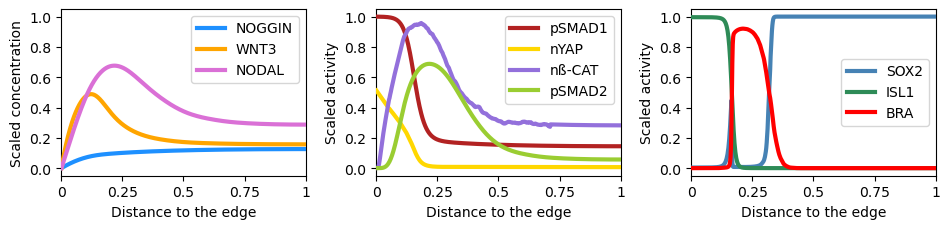

In [7]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_mp, np.flip(ligands_mp[0,-1])/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_mp, np.flip(ligands_mp[1,-1])/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_mp, np.flip(ligands_mp[2,-1])/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_mp, np.flip(TFs_mp[0,-1]), c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_mp, np.flip(TFs_mp[1,-1]), c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_mp, np.flip(TFs_mp[2,-1]), c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_mp, np.flip(TFs_mp[3,-1]), c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_mp, np.flip(fates_mp[0,-1]), c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_mp, np.flip(fates_mp[1,-1]), c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_mp, np.flip(fates_mp[2,-1]), c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Distance to the edge')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 250.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,62.5,125.,187.7,250.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Perturbation 1: TRULI

In [8]:
# Micropattern parameters
param["T"] = T_mp
param["x"] = np.linspace(0., 250., 562)
param["K_S1"] = compute_K1_mp(param)

# Constant nYAP everywhere
param["Y_f"] = 0.4

# Other parameters
param["p_O"] = 5.
param["p1_W"] = 30.
param["p_N"] = 0.01

# Simulations
x_p1, ligands_p1, TFs_p1, fates_p1 = sim_FIG5_mp(param)

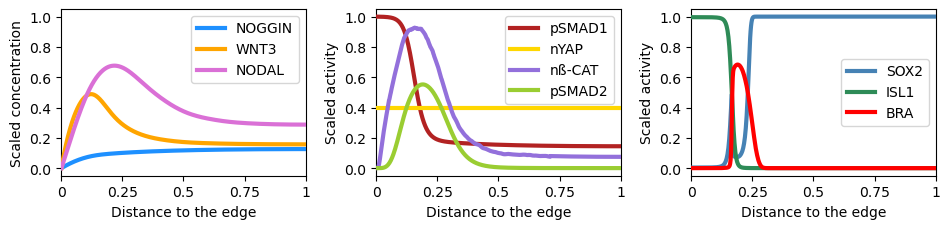

In [9]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_p1, np.flip(ligands_mp[0,-1])/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_p1, np.flip(ligands_mp[1,-1])/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_p1, np.flip(ligands_mp[2,-1])/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_p1, np.flip(TFs_p1[0,-1]), c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_p1, np.flip(TFs_p1[1,-1]), c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_p1, np.flip(TFs_p1[2,-1]), c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_p1, np.flip(TFs_p1[3,-1]), c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_p1, np.flip(fates_p1[0,-1]), c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_p1, np.flip(fates_p1[1,-1]), c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_p1, np.flip(fates_p1[2,-1]), c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Distance to the edge')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 250.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,62.5,125.,187.7,250.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Perturbation 2: NODALi

In [10]:
# Micropattern parameters
param["T"] = T_mp
param["x"] = np.linspace(0., 250., 562)
param["K_S1"] = compute_K1_mp(param)

# No NODAL
param["p_O"] = 0.

# Other parameters
param["Y_f"] = 0.
param["p1_W"] = 30.
param["p_N"] = 0.01

# Simulations
x_p2, ligands_p2, TFs_p2, fates_p2 = sim_FIG5_mp(param)

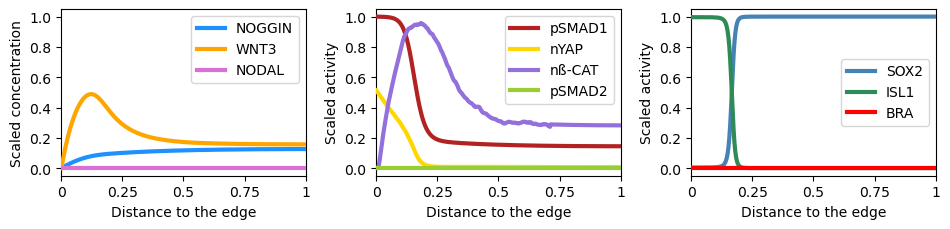

In [11]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_p2, np.flip(ligands_p2[0,-1])/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_p2, np.flip(ligands_p2[1,-1])/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_p2, np.flip(ligands_p2[2,-1]), c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_p2, np.flip(TFs_p2[0,-1]), c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_p2, np.flip(TFs_p2[1,-1]), c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_p2, np.flip(TFs_p2[2,-1]), c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_p2, np.flip(TFs_p2[3,-1]), c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_p2, np.flip(fates_p2[0,-1]), c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_p2, np.flip(fates_p2[1,-1]), c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_p2, np.flip(fates_p2[2,-1]), c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Distance to the edge')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 250.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,62.5,125.,187.7,250.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Perturbation 3: WNTi

In [12]:
# Micropattern parameters
param["T"] = T_mp
param["x"] = np.linspace(0., 250., 562)
param["K_S1"] = compute_K1_mp(param)

# No WNT
param["p1_W"] = 0.

# Other parameters
param["Y_f"] = 0.
param["p_O"] = 5.
param["p_N"] = 0.01

# Simulations
x_p3, ligands_p3, TFs_p3, fates_p3 = sim_FIG5_mp(param)

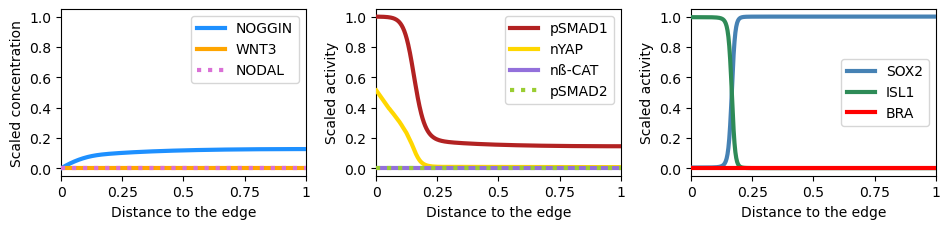

In [13]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_p3, np.flip(ligands_p3[0,-1])/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_p3, np.flip(ligands_p3[1,-1]), c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_p3, np.flip(ligands_p3[2,-1]), c='orchid', lw=3, ls=':', label='NODAL', zorder=8)

# TFs
ax[1].plot(x_p3, np.flip(TFs_p3[0,-1]), c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_p3, np.flip(TFs_p3[1,-1]), c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_p3, np.flip(TFs_p3[2,-1]), c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_p3, np.flip(TFs_p3[3,-1]), c='yellowgreen', lw=3, ls=':', label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_p3, np.flip(fates_p3[0,-1]), c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_p3, np.flip(fates_p3[1,-1]), c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_p3, np.flip(fates_p3[2,-1]), c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Distance to the edge')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 250.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,62.5,125.,187.7,250.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Perturbation 4: NOGGIN-KO

In [14]:
# Micropattern parameters
param["T"] = T_mp
param["x"] = np.linspace(0., 250., 562)
param["K_S1"] = compute_K1_mp(param)

# No NOGGIN
param["p_N"] = 0.

# Other parameters
param["Y_f"] = 0.
param["p_O"] = 5.
param["p1_W"] = 30.

# Simulations
x_p4, ligands_p4, TFs_p4, fates_p4 = sim_FIG5_mp(param)

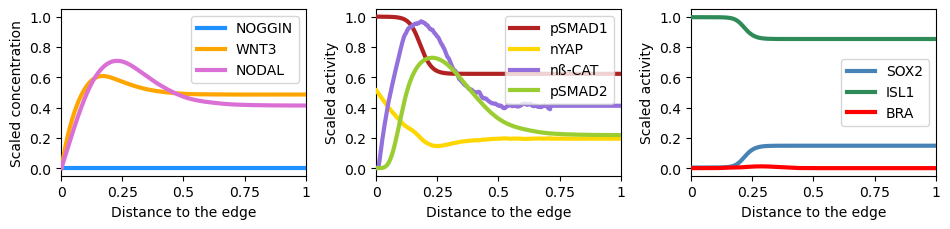

In [15]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_p4, np.flip(ligands_p4[0,-1]), c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_p4, np.flip(ligands_p4[1,-1])/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_p4, np.flip(ligands_p4[2,-1])/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_p4, np.flip(TFs_p4[0,-1]), c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_p4, np.flip(TFs_p4[1,-1]), c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_p4, np.flip(TFs_p4[2,-1]), c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_p4, np.flip(TFs_p4[3,-1]), c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_p4, np.flip(fates_p4[0,-1]), c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_p4, np.flip(fates_p4[1,-1]), c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_p4, np.flip(fates_p4[2,-1]), c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Distance to the edge')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 250.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,62.5,125.,187.7,250.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Simulations (light activation, low tension)

In [16]:
# Light-activation parameters
param["T"] = 0.415   # Low tension regime
param["x"] = np.linspace(-3700., 3700., 1000)
param["prod_B"] = compute_BMP4_prod(param)

# No perturbation
param["Y_f"] = 0.
param["p_O"] = 5.
param["p1_W"] = 30.
param["p_N"] = 0.01

# Simulations
x_low, ligands_low, TFs_low, fates_low = sim_FIG5_light(param)

<br>

Figure 5H-J

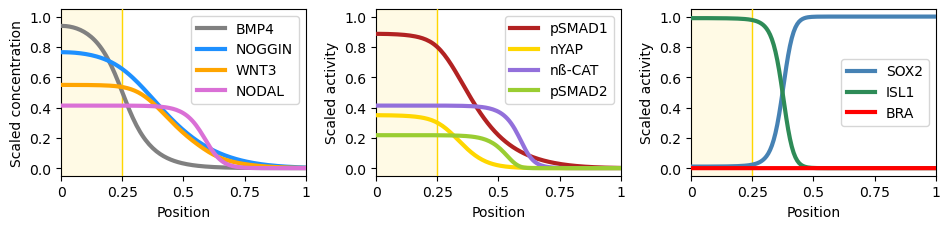

In [17]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_low, ligands_low[0,-1]/alpha_B, c='grey', lw=3, label='BMP4', zorder=8)
ax[0].plot(x_low, ligands_low[1,-1]/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_low, ligands_low[2,-1]/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_low, ligands_low[3,-1]/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_low, TFs_low[0,-1], c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_low, TFs_low[1,-1], c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_low, TFs_low[2,-1], c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_low, TFs_low[3,-1], c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_low, fates_low[0,-1], c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_low, fates_low[1,-1], c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_low, fates_low[2,-1], c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Position')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 800.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,250.,500.,750.,1000.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    ax[k].fill_between([0.,x_L], [-0.05, -0.05], [1.05, 1.05], color='gold', alpha=0.1)
    ax[k].plot([x_L,x_L], [-0.05, 1.05], c='gold', lw=1., zorder=6)
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Simulations (light activation, high tension)

In [18]:
# Light-activation parameters
param["T"] = 0.658   # High tension regime
param["x"] = np.linspace(-3700., 3700., 1000)
param["prod_B"] = compute_BMP4_prod(param)

# No perturbation
param["Y_f"] = 0.
param["p_O"] = 5.
param["p1_W"] = 30.
param["p_N"] = 0.01

# Simulations
x_high, ligands_high, TFs_high, fates_high = sim_FIG5_light(param)

<br>

Figure 5L-N

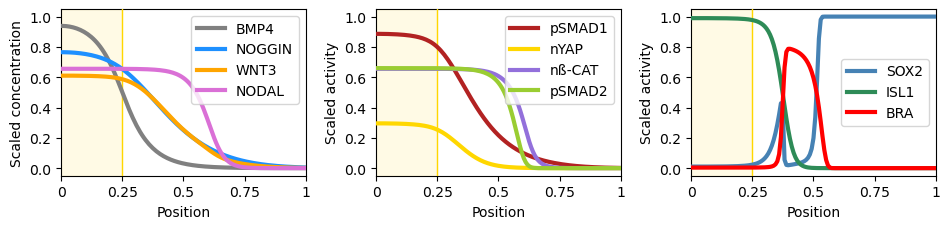

In [19]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x_high, ligands_high[0,-1]/alpha_B, c='grey', lw=3, label='BMP4', zorder=8)
ax[0].plot(x_high, ligands_high[1,-1]/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x_high, ligands_high[2,-1]/alpha_W, c='orange', lw=3, label='WNT3', zorder=8)
ax[0].plot(x_high, ligands_high[3,-1]/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x_high, TFs_high[0,-1], c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x_high, TFs_high[1,-1], c='gold', lw=3, label='nYAP', zorder=8)
ax[1].plot(x_high, TFs_high[2,-1], c='mediumpurple', lw=3, label='nß-CAT', zorder=8)
ax[1].plot(x_high, TFs_high[3,-1], c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x_high, fates_high[0,-1], c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x_high, fates_high[1,-1], c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x_high, fates_high[2,-1], c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Position')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 800.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,250.,500.,750.,1000.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    ax[k].fill_between([0.,x_L], [-0.05, -0.05], [1.05, 1.05], color='gold', alpha=0.1)
    ax[k].plot([x_L,x_L], [-0.05, 1.05], c='gold', lw=1., zorder=6)
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Supplementary Figure: comparing ctrl vs. gel TF activity

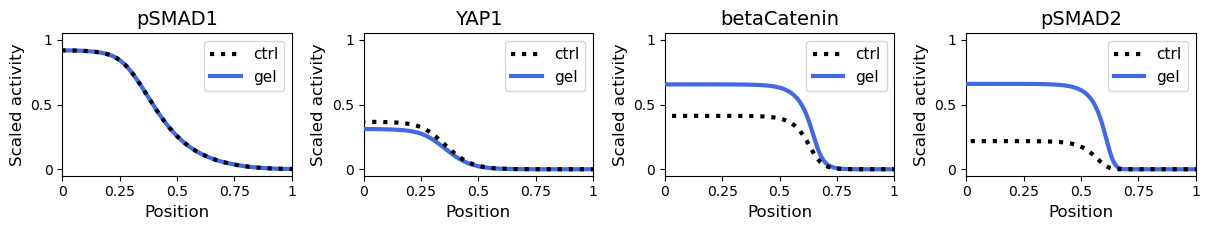

In [20]:
fig, ax = plt.subplots(ncols=4, figsize=[12.2, 2.4])
TF_label = ['pSMAD1', 'YAP1', 'betaCatenin', 'pSMAD2']

# pSMAD1, nYAP, nß-Catenin, pSMAD2
for k in range(4):
    
    # TF
    ax[k].plot(x_low, TFs_low[k,1], c='k', ls=':',  lw=3, label='ctrl', zorder=8)
    ax[k].plot(x_high, TFs_high[k,1], c='royalblue', lw=3, label='gel', zorder=7)
    
    # Axes, legend, light domain
    ax[k].set_title(TF_label[k], fontsize=14)
    ax[k].set_xlabel('Position', fontsize=12)
    ax[k].set_ylabel('Scaled activity', fontsize=12)
    ax[k].set_xlim([0., 1000.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,250.,500.,750.,1000.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1], fontsize=10)
    ax[k].set_yticks([0.,0.5,1.])
    ax[k].set_yticklabels([0,0.5,1], fontsize=10)
    leg = ax[k].legend(fontsize=11)
    leg.set_zorder(12)

fig.tight_layout()